In [49]:
import jax.numpy as jnp
from jax import random
import jax
from flax.training import train_state
import optax
from flax import linen as nn
from tqdm.notebook import tqdm
# Optionally, you can save the losses to a file or plot them
import matplotlib.pyplot as plt
import numpy as np
import sys

jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')


In [3]:
# Model
class NNFunc(nn.Module):
    alpha: float
    eps: float = 0.25
    D: int = 100
    N: int = 500

    def setup(self):
        # This initialization didn't work hmmm 
        # self.W = self.param('W', nn.initializers.normal(), (self.N,self.D))
        self.W = self.param('W', random.normal, (self.N,self.D))

    def __call__(self, X):
        h = jnp.dot(self.W, X) / jnp.sqrt(self.D)
        f = self.alpha * jnp.mean(
            h + 0.5 * self.eps * h**2, axis=0
        )
        return f

In [4]:
# Create data
D = 100
P = 450
N = 500

X = random.normal(random.PRNGKey(0), (D,P))
Xt = random.normal(random.PRNGKey(1), (D,1000))
beta = random.normal(random.PRNGKey(2), (D,))

def target_fn(beta, X):
    return (X.T @ beta / jnp.sqrt(D))**2

y = target_fn(beta, X)
yt = target_fn(beta,Xt)



In [5]:
def train(alphas = [2**(-5),0.25,0.5,1.0,2.0,4.0,8.0,16,32],
          iterations = 10001,
        #   precond='smw' # 'gn' or None # It's really slow to have the if somehow; I thought the compilation would help but it slows down
        # easier to just uncomment in code 
        ):
    all_tr_losses = []
    all_te_losses = []

    # Optimizer
    eta = 0.5 * N
    # eta = 5e-4 * N # This works.... a little bit for Gauss-Newton 
    tx = optax.sgd(learning_rate=eta)


    for alpha in alphas: 
        # Make model 
        # Initialize the model
        model = NNFunc(alpha=alpha, eps=0.25, D=D, N=N)
        params = model.init(jax.random.PRNGKey(1), X)
        state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=tx)

        # Save intiializer 
        init_params = state.params

        @jax.jit
        def loss_fn(params, x, y):
            loss = jnp.mean(
                (state.apply_fn(params, x) - state.apply_fn(init_params, x) - y) ** 2 / alpha**2
            )
            return loss

        @jax.jit
        def train_step(state):
            loss, grads = jax.value_and_grad(loss_fn)(state.params, X, y)

            # if precond == 'smw':
            # TODO: change alpha to match Variance as suggested by Alexey
            print('Running SMW')
            lamb = 1e-1 / alpha # THIS IS THE SCALING HERE

            _, jvp_output = jax.jvp(lambda p: state.apply_fn(p, X), (state.params,), (grads,))
            jacobian_fn = jax.jacrev(
                lambda params, x: state.apply_fn(params, x)
            )(state.params, X)
            flat_jacobian = []
            for layer in jacobian_fn['params'].values():
                flat_jacobian.append(layer.reshape(450, -1))
            jacobian_fn = jnp.concatenate(flat_jacobian, axis=1)
            mat = jacobian_fn @ jacobian_fn.T

            out = jnp.linalg.solve(jnp.eye(mat.shape[0]) + 1 / lamb * mat, jvp_output / (lamb ** 2))
            _, vjp_fn = jax.vjp( lambda params, x: state.apply_fn(params, x), state.params, X)
            adjustment = vjp_fn(out)[0] 
            grads = jax.tree.map(lambda a, b: 1 / lamb * a - b, grads, adjustment)

            # elif precond == 'gn-exact':
            #     flat_jacobian = []
            #     jacobian_fn = jax.jacrev(
            #         lambda params, x: state.apply_fn(params, x)
            #     )(state.params, X)
            #     for layer in jacobian_fn['params'].values():
            #         flat_jacobian.append(layer.reshape(450, -1))
            #     jacobian_fn = jnp.concatenate(flat_jacobian, axis=1)
            #     u, s, vh = jnp.linalg.svd(jacobian_fn, full_matrices=False)

            #     # Compute inverse
            #     threshold = 1e-3
            #     s_inv = jnp.where(s > 1e-3, s ** -2, threshold)

            #     # Apply to grads
            #     flattened, back = jax.flatten_util.ravel_pytree(grads)
            #     my_change =  vh.T @ jnp.diag(s_inv) @ vh @ flattened
            #     grads = back(alpha * my_change)


            state = state.apply_gradients(grads=grads)
            return state, loss

        tr_losses = []
        te_losses = []
        for t in tqdm(range(iterations)):
            state, loss = train_step(state)
            
            if t % 2 == 0:
                train_loss = alpha**2*loss_fn(state.params, X, y)
                test_loss = alpha**2*loss_fn(state.params, Xt, yt)
                tr_losses += [train_loss]
                te_losses += [test_loss]
                sys.stdout.write(f'\r t: {t} | train loss: {train_loss} | test loss: {test_loss}')

            if t % 10000 == 0:
                print(" ")

        all_tr_losses += [tr_losses]
        all_te_losses += [te_losses]
    
    return all_tr_losses, all_te_losses


In [ ]:

alphas = [2**(-5),0.25,0.5,1.0,2.0,4.0,8.0,16,32]
all_tr_loss_original, all_te_losses_original = train(alphas=alphas, iterations=60000) # This is to get original paper


  0%|          | 0/60000 [00:00<?, ?it/s]

 t: 0 | train loss: 3.4646077156066895 | test loss: 3.524923324584961 
 t: 10000 | train loss: 1.4506926163448952e-05 | test loss: 0.006856084335595369 
 t: 20000 | train loss: 3.2048374123405665e-06 | test loss: 0.003376353532075882 
 t: 30000 | train loss: 1.1486513358249795e-06 | test loss: 0.002339910017326474 
 t: 40000 | train loss: 5.023198355047498e-07 | test loss: 0.0018674402963370085 
 t: 50000 | train loss: 2.4469963477713463e-07 | test loss: 0.0016063298098742962 
 t: 59998 | train loss: 1.2745491062560177e-07 | test loss: 0.0014459381345659494

  0%|          | 0/60000 [00:00<?, ?it/s]

 t: 0 | train loss: 3.466231346130371 | test loss: 3.525538682937622 
 t: 10000 | train loss: 0.0002500767295714468 | test loss: 0.11785851418972015 
 t: 20000 | train loss: 4.9725018470780924e-05 | test loss: 0.07270868122577667 
 t: 30000 | train loss: 1.574383168190252e-05 | test loss: 0.05783333256840706 4
 t: 40000 | train loss: 6.01013107370818e-06 | test loss: 0.05078238993883133 54
 t: 50000 | train loss: 2.5317488052678527e-06 | test loss: 0.046874549239873886 
 t: 59998 | train loss: 1.13101884835487e-06 | test loss: 0.04451952502131462724

  0%|          | 0/60000 [00:00<?, ?it/s]

...

 t: 0 | train loss: 3.466456174850464 | test loss: 3.5256378650665283 
 t: 10000 | train loss: 0.013356215320527554 | test loss: 1.7535637617111206 
 t: 20000 | train loss: 0.001424293965101242 | test loss: 1.6007925271987915 
 t: 30000 | train loss: 0.0002352486626477912 | test loss: 1.5575639009475708 
 t: 40000 | train loss: 4.623939821613021e-05 | test loss: 1.5417122840881348 
 t: 50000 | train loss: 9.988561032514554e-06 | test loss: 1.5352697372436523 
 t: 59998 | train loss: 2.297424316566321e-06 | test loss: 1.53246080875396737

  0%|          | 0/60000 [00:00<?, ?it/s]

 t: 0 | train loss: 3.4664599895477295 | test loss: 3.525642156600952 
 t: 10000 | train loss: 0.025647679343819618 | test loss: 2.1312153339385986 
 t: 20000 | train loss: 0.0025036500301212072 | test loss: 1.9961570501327515 
 t: 30000 | train loss: 0.00038346744258888066 | test loss: 1.96142578125 5219
 t: 40000 | train loss: 6.945089990040287e-05 | test loss: 1.9498201608657837 
 t: 50000 | train loss: 1.3715835848415736e-05 | test loss: 1.9454809427261353 
 t: 59998 | train loss: 2.870767275453545e-06 | test loss: 1.94375121593475342

  0%|          | 0/60000 [00:00<?, ?it/s]

 t: 0 | train loss: 3.466461658477783 | test loss: 3.525581121444702 
 t: 10000 | train loss: 0.045791346579790115 | test loss: 2.4124157428741455 
 t: 20000 | train loss: 0.004332651384174824 | test loss: 2.2991552352905273 
 t: 30000 | train loss: 0.0006448145722970366 | test loss: 2.270620107650757 
 t: 40000 | train loss: 0.00011504488065838814 | test loss: 2.261608362197876 
 t: 50000 | train loss: 2.257806590932887e-05 | test loss: 2.258291006088257 5
 t: 59998 | train loss: 4.810815880773589e-06 | test loss: 2.25711202621459967

0.03125
0.25
0.5
1.0
2.0
4.0
8.0
16


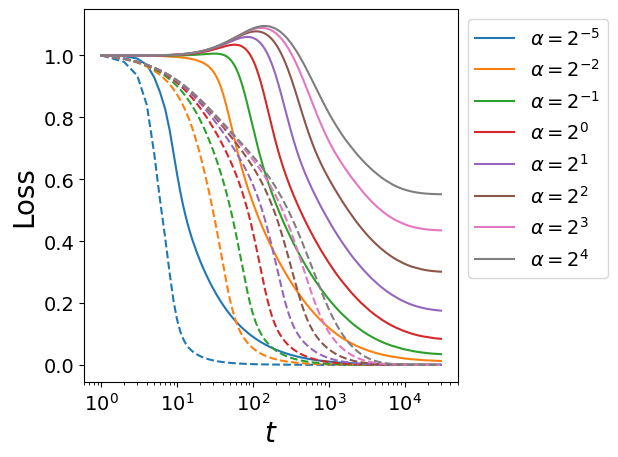

In [12]:
plt.rcParams.update({'font.size': 14})
plt.figure()
for i,alpha in enumerate(alphas[:-1]):
    print(alpha)
    plt.plot(jnp.linspace(1,len(all_tr_loss_original[i]),len(all_tr_loss_original[i])), jnp.array(all_tr_loss_original[i]) / all_tr_loss_original[i][0], '--',  color = f'C{i}')
    plt.plot(jnp.linspace(1,len(all_tr_loss_original[i]),len(all_tr_loss_original[i])), jnp.array(all_te_losses_original[i]) / all_te_losses_original[i][0],  color = f'C{i}', label = r'$\alpha = 2^{%0.0f}$' % jnp.log2(alpha))

plt.xscale('log')
plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel('Loss',fontsize = 20)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()



  0%|          | 0/10001 [00:00<?, ?it/s]

 t: 0 | train loss: 3.479227066040039 | test loss: 3.5258617401123047 
 t: 10000 | train loss: 0.00012286702985875309 | test loss: 0.022948896512389183 


  0%|          | 0/10001 [00:00<?, ?it/s]

 t: 0 | train loss: 3.437218427658081 | test loss: 3.5246596336364746 
 t: 10000 | train loss: 2.7896374376723543e-05 | test loss: 0.06442392617464066 


  0%|          | 0/10001 [00:00<?, ?it/s]

...

 t: 0 | train loss: 3.4085471630096436 | test loss: 3.50053071975708 
 t: 10000 | train loss: 8.539234386262251e-08 | test loss: 1.538219928741455 


  0%|          | 0/10001 [00:00<?, ?it/s]

 t: 0 | train loss: 3.4579601287841797 | test loss: 3.5172998905181885 
 t: 10000 | train loss: 1.5944848996696237e-07 | test loss: 1.9498913288116455 


  0%|          | 0/10001 [00:00<?, ?it/s]

 t: 0 | train loss: 3.47812557220459 | test loss: 3.523800849914551 
 t: 10000 | train loss: 4.357695502221759e-07 | test loss: 2.259237766265869 
0.03125
0.25
0.5
1.0
2.0
4.0
8.0
16


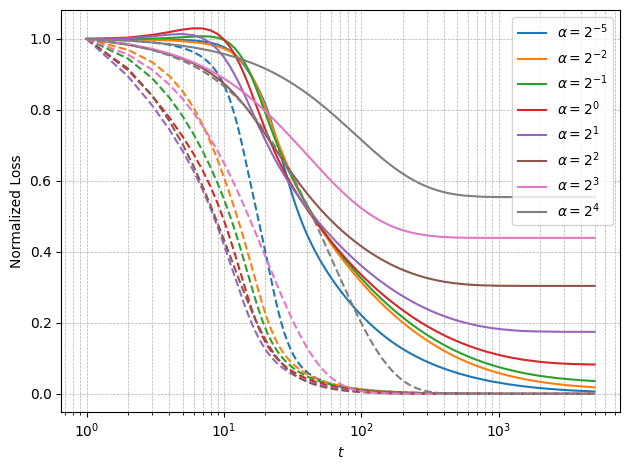

In [16]:
alphas = [2**(-5),0.25,0.5,1.0,2.0,4.0,8.0,16,32]
all_tr_losses, all_te_losses = train(alphas=alphas, iterations=10001) # Uncomment code to get SMW


plt.rcParams.update({'font.size': 10})
plt.figure()
for i,alpha in enumerate(alphas[:-1]):
    print(alpha)
    plt.plot(jnp.linspace(1,len(all_tr_losses[i]),len(all_tr_losses[i])), jnp.array(all_tr_losses[i]) / all_tr_losses[i][0], '--',  color = f'C{i}')
    plt.plot(jnp.linspace(1,len(all_tr_losses[i]),len(all_tr_losses[i])), jnp.array(all_te_losses[i]) / all_te_losses[i][0],  color = f'C{i}', label = r'$\alpha = 2^{%0.0f}$' % jnp.log2(alpha))

plt.xscale('log')
plt.xlabel(r'$t$')
plt.ylabel('Normalized Loss')
plt.legend(loc='upper right')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()



0.03125
0.25
0.5
1.0
2.0
4.0
8.0
16
0.03125
0.25
0.5
1.0
2.0
4.0
8.0
16


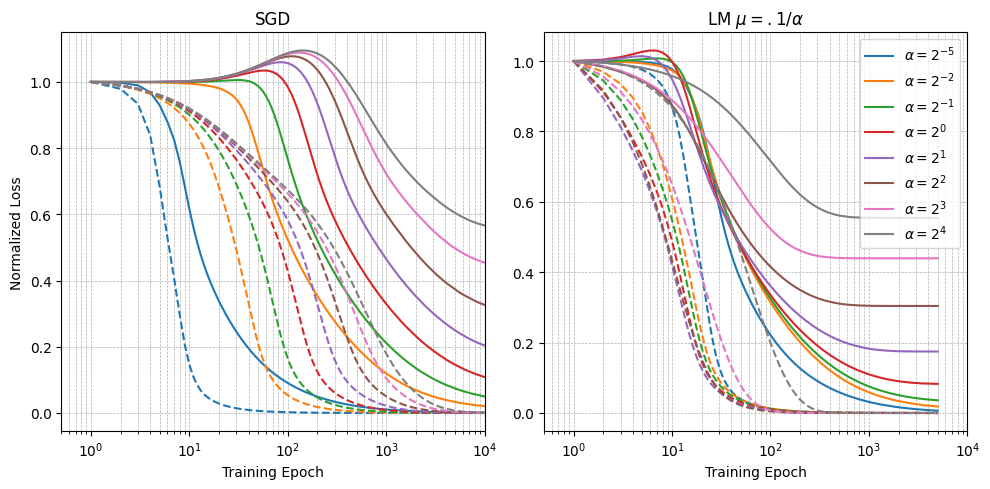

In [33]:
fig, subfigs = plt.subplots(1, 2, figsize=(10, 5))  # 1 row


for i,alpha in enumerate(alphas[:-1]):
    print(alpha)
    subfigs[1].semilogx(jnp.linspace(1,len(all_tr_losses[i]),len(all_tr_losses[i])), jnp.array(all_tr_losses[i]) / all_tr_losses[i][0], '--',  color = f'C{i}')
    subfigs[1].semilogx(jnp.linspace(1,len(all_tr_losses[i]),len(all_tr_losses[i])), jnp.array(all_te_losses[i]) / all_te_losses[i][0],  color = f'C{i}', label = r'$\alpha = 2^{%0.0f}$' % jnp.log2(alpha))


subfigs[1].set_xlabel(r'Training Epoch')
subfigs[1].legend(loc='upper right')
subfigs[1].grid(True, which='both', linestyle='--', linewidth=0.5)
subfigs[1].set_xlim(.5, 1e4)
subfigs[1].set_title(r'LM $\mu=.1/\alpha$')

for i,alpha in enumerate(alphas[:-1]):
    print(alpha)
    subfigs[0].semilogx(jnp.linspace(1,len(all_tr_loss_original[i]),len(all_tr_loss_original[i])), jnp.array(all_tr_loss_original[i]) / all_tr_loss_original[i][0], '--',  color = f'C{i}')
    subfigs[0].semilogx(jnp.linspace(1,len(all_tr_loss_original[i]),len(all_tr_loss_original[i])), jnp.array(all_te_losses_original[i]) / all_te_losses_original[i][0],  color = f'C{i}', label = r'$\alpha = 2^{%0.0f}$' % jnp.log2(alpha))


subfigs[0].set_xlabel(r'Training Epoch')
subfigs[0].set_ylabel('Normalized Loss')
subfigs[0].grid(True, which='both', linestyle='--', linewidth=0.5)
subfigs[0].set_xlim(.5, 1e4)
subfigs[0].set_title('SGD')

plt.tight_layout()
plt.savefig('grokking.png')
plt.show()


# Scaling with epsilon

I THINK WE NEED TO USE HIGHER PRECISION HERE!!!

In [54]:
def train_eps(epsilons = [0.25,0.5,1.0,2.0,4.0],
          iterations = 50001,
        #   precond='smw' # 'gn' or None # It's really slow to have the if somehow; I thought the compilation would help but it slows down
        # easier to just uncomment in code 
        ):
    all_tr_losses = []
    all_te_losses = []
    
    # Optimizer
    eta = 0.5 * N
    # eta = 5e-4 * N # This works.... a little bit for Gauss-Newton 
    tx = optax.sgd(learning_rate=eta)

    alpha = 1.0
    for epsilon in epsilons: 
        # Make model 
        # Initialize the model
        model = NNFunc(alpha=alpha, eps=epsilon, D=D, N=N)
        params = model.init(jax.random.PRNGKey(1), X)
        state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=tx)

        # Save intiializer 
        init_params = state.params

        @jax.jit
        def loss_fn(params, x, y):
            loss = jnp.mean(
                (state.apply_fn(params, x) - state.apply_fn(init_params, x) - y) ** 2 / alpha**2
            )
            return loss

        @jax.jit
        def train_step(state):
            loss, grads = jax.value_and_grad(loss_fn)(state.params, X, y)

            # if precond == 'smw':
            # TODO: change alpha to match Variance as suggested by Alexey
            print('Running SMW')
            lamb = 1e-1

            _, jvp_output = jax.jvp(lambda p: state.apply_fn(p, X), (state.params,), (grads,))
            jacobian_fn = jax.jacrev(
                lambda params, x: state.apply_fn(params, x)
            )(state.params, X)
            flat_jacobian = []
            for layer in jacobian_fn['params'].values():
                flat_jacobian.append(layer.reshape(450, -1))
            jacobian_fn = jnp.concatenate(flat_jacobian, axis=1)
            mat = jacobian_fn @ jacobian_fn.T
        
            out = jnp.linalg.solve(jnp.eye(mat.shape[0]) + 1 / lamb * mat, jvp_output / (lamb ** 2))
            _, vjp_fn = jax.vjp( lambda params, x: state.apply_fn(params, x), state.params, X)
            adjustment = vjp_fn(out)[0] 
            grads = jax.tree.map(lambda a, b: 1 / lamb * a - b, grads, adjustment)

            # elif precond == 'gn-exact':
            #     flat_jacobian = []
            #     jacobian_fn = jax.jacrev(
            #         lambda params, x: state.apply_fn(params, x)
            #     )(state.params, X)
            #     for layer in jacobian_fn['params'].values():
            #         flat_jacobian.append(layer.reshape(450, -1))
            #     jacobian_fn = jnp.concatenate(flat_jacobian, axis=1)
            #     u, s, vh = jnp.linalg.svd(jacobian_fn, full_matrices=False)

            #     # Compute inverse
            #     threshold = 1e-3
            #     s_inv = jnp.where(s > 1e-3, s ** -2, threshold)

            #     # Apply to grads
            #     flattened, back = jax.flatten_util.ravel_pytree(grads)
            #     my_change =  vh.T @ jnp.diag(s_inv) @ vh @ flattened
            #     grads = back(alpha * my_change)
            print(loss.dtype)
            state = state.apply_gradients(grads=grads)
            return state, loss
            
        @jax.jit
        def train_step_sgd(state):
            loss, grads = jax.value_and_grad(loss_fn)(state.params, X, y)
            state = state.apply_gradients(grads=grads)
            return state, loss

        tr_losses = []
        te_losses = []
        for t in tqdm(range(iterations)):
            state, loss = train_step(state)
            
            if t % 2 == 0:
                train_loss = alpha**2*loss_fn(state.params, X, y)
                test_loss = alpha**2*loss_fn(state.params, Xt, yt)
                tr_losses += [train_loss]
                te_losses += [test_loss]
                sys.stdout.write(f'\r t: {t} | train loss: {train_loss} | test loss: {test_loss}')

            if t % 10000 == 0:
                print(" ")
        # for t in tqdm(range(iterations)):
        #     state, loss = train_step_sgd(state)
            
        #     if t % 2 == 0:
        #         train_loss = alpha**2*loss_fn(state.params, X, y)
        #         test_loss = alpha**2*loss_fn(state.params, Xt, yt)
        #         tr_losses += [train_loss]
        #         te_losses += [test_loss]
        #         sys.stdout.write(f'\r t: {t} | train loss: {train_loss} | test loss: {test_loss}')

        #     if t % 10000 == 0:
        #         print(" ")

        all_tr_losses += [tr_losses]
        all_te_losses += [te_losses]
    
    return all_tr_losses, all_te_losses


In [55]:
# epsilons = [2 ** (-4), 2 ** (-3), 0.25,0.5,1.0]
epsilons = [.25, .5, 1.0, 2.0, 4.0]
# all_tr_losses, all_te_losses = train_eps(epsilons = epsilons,
#           iterations = 50001,
#         #   precond='smw' # 'gn' or None # It's really slow to have the if somehow; I thought the compilation would help but it slows down
#         # easier to just uncomment in code 
#         )
all_tr_losses_smw, all_te_losses_smw = train_eps(epsilons = epsilons,
          iterations = 10001,
        #   precond='smw' # 'gn' or None # It's really slow to have the if somehow; I thought the compilation would help but it slows down
        # easier to just uncomment in code 
        )

  0%|          | 0/10001 [00:00<?, ?it/s]

Running SMW
float64
 t: 0 | train loss: 3.3168616033373697 | test loss: 3.524105349041118 
 t: 10000 | train loss: 6.732707259818089e-08 | test loss: 0.29285173838124207 


  0%|          | 0/10001 [00:00<?, ?it/s]

Running SMW
float64
 t: 0 | train loss: 3.232288586814868 | test loss: 3.47415580287892 
 t: 10000 | train loss: 2.929484178856069e-20 | test loss: 0.6030724757778707 


  0%|          | 0/10001 [00:00<?, ?it/s]

Running SMW
float64
 t: 0 | train loss: 2.923259194038561 | test loss: 3.2948587744331213 
 t: 10000 | train loss: 1.215749697160924e-31 | test loss: 1.0072294169083114 


  0%|          | 0/10001 [00:00<?, ?it/s]

Running SMW
float64
 t: 0 | train loss: 2.056438762745871 | test loss: 2.8272854828798146 
 t: 10000 | train loss: 3.9497827268357605e-31 | test loss: 1.3708195347412622 


  0%|          | 0/10001 [00:00<?, ?it/s]

Running SMW
float64
 t: 0 | train loss: 0.8021570041699146 | test loss: 2.263355358266642 
 t: 10000 | train loss: 1.5647932567175682e-30 | test loss: 1.668345815069307 


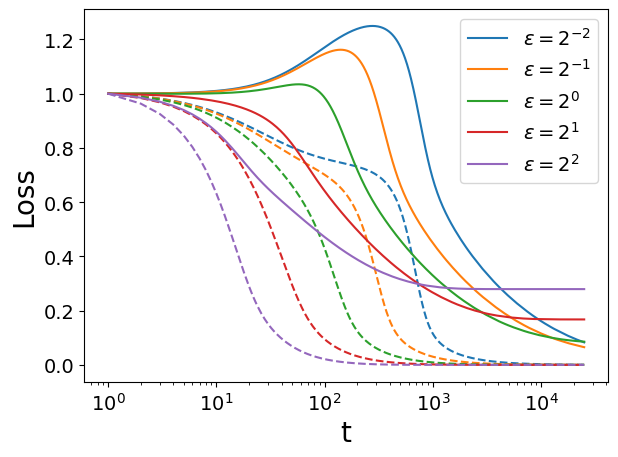

In [39]:
plt.rcParams.update({'font.size': 14})
plt.figure()
for i,wscale in enumerate(epsilons):
    plt.plot(jnp.linspace(1,len(all_tr_losses[i]),len(all_tr_losses[i])), jnp.array(all_tr_losses[i]) / all_tr_losses[i][0], '--',  color = f'C{i}')
    plt.plot(jnp.linspace(1,len(all_tr_losses[i]),len(all_tr_losses[i])), jnp.array(all_te_losses[i]) / all_te_losses[i][0],  color = f'C{i}', label = r'$\varepsilon = 2^{%0.0f}$' % jnp.log2(wscale))
plt.xscale('log')
plt.xlabel('t',fontsize = 20)
plt.ylabel('Loss',fontsize = 20)
plt.legend()
plt.tight_layout()
plt.show()


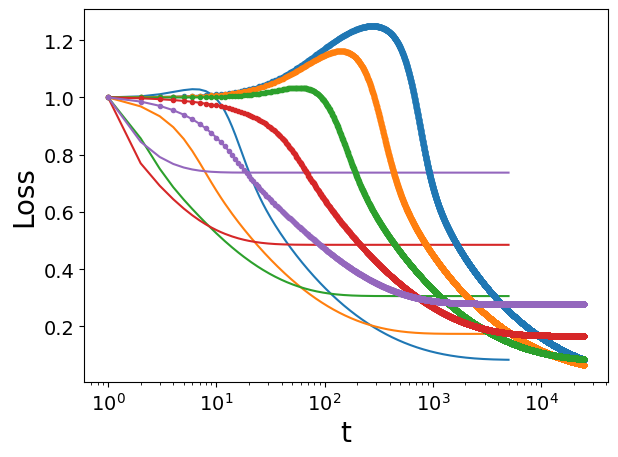

In [61]:
epsilons = [0.25,0.5,1.0,2.0,4.0]
plt.rcParams.update({'font.size': 14})
plt.figure()
for i,wscale in enumerate(epsilons):
    # plt.plot(jnp.linspace(1,len(all_tr_losses_smw[i]),len(all_tr_losses_smw[i])), jnp.array(all_tr_losses_smw[i]) / all_tr_losses_smw[i][0], '--',  color = f'C{i}')
    plt.plot(jnp.linspace(1,len(all_tr_losses_smw[i]),len(all_tr_losses_smw[i])), jnp.array(all_te_losses_smw[i]) / all_te_losses_smw[i][0],  color = f'C{i}', label = r'$\varepsilon = 2^{%0.0f}$' % jnp.log2(wscale))

for i,wscale in enumerate(epsilons):
    # plt.plot(jnp.linspace(1,len(all_tr_losses[i]),len(all_tr_losses[i])), jnp.array(all_tr_losses[i]) / all_tr_losses[i][0], '--',  color = f'C{i}')
    plt.plot(jnp.linspace(1,len(all_tr_losses[i]),len(all_tr_losses[i])), jnp.array(all_te_losses[i]) / all_te_losses[i][0], '.-',  color = f'C{i}', label = r'$\varepsilon = 2^{%0.0f}$' % jnp.log2(wscale))

plt.xscale('log')
plt.xlabel('t',fontsize = 20)
plt.ylabel('Loss',fontsize = 20)
plt.tight_layout()
plt.show()
